# Знакомство с библиотекой PyTorch

[PyTorch](https://pytorch.org/) - библиотека для глубокого обучения, разработанная компанией Meta. Она позволяет быстро создавать и обучать нейронные сети благодаря двум ключевым особенностям:

1. **Тензоры** - структура данных, похожая на массивы NumPy, но рассчитанная на работу с графическими ускорителями (GPU).
2. **Autograd** - механизм автоматического вычисления градиентов, который используется при обучении нейронных сетей методом обратного распространения ошибки.

В этом уроке мы познакомимся с основными операциями PyTorch, которые понадобятся во всех следующих уроках курса.

In [1]:
import torch
import numpy as np
print("Версия PyTorch:", torch.__version__)

Версия PyTorch: 2.1.0+rocm5.6


## Тензоры

Тензор - основная структура данных в PyTorch. По сути это многомерный массив чисел. Скаляр - тензор нулевой размерности, вектор - первой, матрица - второй и так далее.

Создадим тензор из списка Python.

In [2]:
t = torch.tensor([[1, 2, 3], 
                  [4, 5, 6]])
print(t)

tensor([[1, 2, 3],
        [4, 5, 6]])


Помимо создания тензоров из данных, часто используются тензоры, заполненные особыми значениями.


In [3]:
print("Нули:")
print(torch.zeros(1, 3, 3))
print("Единицы:")
print(torch.ones(2, 3))
print("Число 7 везде:")
print(torch.full((2, 3), 7))
print("Случайные числа на отрезке [0, 1):")
print(torch.rand(2, 3))
print("Последовательность чисел:")
print(torch.arange(0, 10, 2))
print("Единичная матрица:")
print(torch.eye(3))

Нули:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
Единицы:
tensor([[1., 1., 1.],
        [1., 1., 1.]])
Число 7 везде:
tensor([[7, 7, 7],
        [7, 7, 7]])
Случайные числа на отрезке [0, 1):
tensor([[0.2192, 0.5390, 0.4141],
        [0.9612, 0.7119, 0.4207]])
Последовательность чисел:
tensor([0, 2, 4, 6, 8])
Единичная матрица:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


## Атрибуты тензора

Каждый тензор имеет размерность (`shape`), тип данных (`dtype`) и устройство (`device`), на котором он расположен.

In [168]:
# t = torch.tensor([[1.0, 2.0, 3.0],
#                   [4.0, 5.0, 6.0]])

t = torch.rand(2, 3, 5, 5)
print("Размерность:", t.shape)
print("Тип данных:", t.dtype)
print("Устройство:", t.device)
print("Число элементов:", t.numel())

Размерность: torch.Size([2, 3, 5, 5])
Тип данных: torch.float32
Устройство: cpu
Число элементов: 150


## Типы данных

PyTorch поддерживает несколько типов данных. По умолчанию целочисленные тензоры создаются как `int64`, а вещественные - как `float32`. Тип можно менять методом `to()`.

In [171]:
# print("Целое число:", torch.tensor(1).dtype)
# print("Вещественное число:", torch.tensor(1.5).dtype)
# print("Логическое значение:", torch.tensor(True).dtype)

t = torch.tensor([1.9, 2.9])
print("Исходный тип:", t.dtype)
print("Как целые:", t.to(torch.int32))
print("Как float16:", t.to(torch.float16))
print("Как float32:", t.to(torch.float32))
print("Обратно во float32:", t.to(torch.int32).to(torch.float32))

Исходный тип: torch.float32
Как целые: tensor([1, 2], dtype=torch.int32)
Как float16: tensor([1.9004, 2.9004], dtype=torch.float16)
Как float32: tensor([1.9000, 2.9000])
Обратно во float32: tensor([1., 2.])


## Арифметические операции

С тензорами работают обычные арифметические операции. Они выполняются поэлементно.

In [7]:
a = torch.tensor([[1., 2.], 
                  [3., 4.]])

b = torch.tensor([[5., 6.], 
                  [7., 8.]])

print("Сумма:")
print(a + b)
print("Разность:")
print(a - b)
print("Поэлементное произведение:")
print(a * b)
print("Деление:")
print(a / b)
print("Возведение в степень:")
print(a ** 2)

Сумма:
tensor([[ 6.,  8.],
        [10., 12.]])
Разность:
tensor([[-4., -4.],
        [-4., -4.]])
Поэлементное произведение:
tensor([[ 5., 12.],
        [21., 32.]])
Деление:
tensor([[0.2000, 0.3333],
        [0.4286, 0.5000]])
Возведение в степень:
tensor([[ 1.,  4.],
        [ 9., 16.]])


Кроме того, есть математические функции, действующие на каждый элемент тензора.


In [173]:
t = torch.tensor([[1., 2., 3.]])

print("Экспонента:")
print(torch.exp(t))
print("Натуральный логарифм:")
print(torch.log(t))
print("Квадратный корень:")
print(torch.sqrt(t))
print("Синус:")
print(torch.sin(t) + torch.sqrt(t))

Экспонента:
tensor([[ 2.7183,  7.3891, 20.0855]])
Натуральный логарифм:
tensor([[0.0000, 0.6931, 1.0986]])
Квадратный корень:
tensor([[1.0000, 1.4142, 1.7321]])
Синус:
tensor([[1.8415, 2.3235, 1.8732]])


## Матричные операции

Для матричного умножения используется оператор `@` или функция `torch.matmul()`.

In [ ]:
5x3 3x6 = [5, 6]


In [4]:
# 5x3 3x6 = [5, 6]
a = torch.rand(5,3)
a.shape

b = torch.rand(3,6)
b.shape
print(a @ b)

tensor([[0.7117, 0.3741, 0.9346, 1.0037, 0.6678, 0.3315],
        [0.9304, 1.3484, 0.7715, 0.2754, 1.4996, 0.8344],
        [0.8623, 0.6528, 1.0662, 0.9716, 0.9663, 0.4935],
        [0.5629, 0.5367, 0.6604, 0.4986, 0.7182, 0.3730],
        [0.6626, 0.7519, 0.4302, 0.4699, 0.8465, 0.5045]])


In [5]:
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[5., 6.], [7., 8.]])

print("Матричное произведение через @:")
print(a @ b)
print("Матричное произведение через matmul:")
print(torch.matmul(a, b))


Матричное произведение через @:
tensor([[19., 22.],
        [43., 50.]])
Матричное произведение через matmul:
tensor([[19., 22.],
        [43., 50.]])


In [8]:
torch.einsum("ij,jk->ik",a,b)

tensor([[19., 22.],
        [43., 50.]])

In [9]:
a = torch.rand(5,3)
b = torch.rand(3,5)
print(torch.matmul(b,a))

tensor([[0.9468, 0.9117, 0.4890],
        [1.0110, 1.1997, 1.1126],
        [1.4184, 1.4936, 0.9753]])


## Операции агрегации

Часто требуется найти сумму, среднее или максимум элементов тензора. Аргумент `dim` задает ось, вдоль которой выполняется операция.

In [10]:
t = torch.tensor([[1., 2., -3.], 
                  [4., 5., 6.]])

print("Сумма всех элементов:", t.sum())
print("Среднее всех элементов:", t.mean())
print("Максимум:", t.max())
print("Минимум:", t.min())

print("Сумма вдоль столбцов (dim=0):")
print(t.sum(dim=0))
print("Сумма вдоль строк (dim=1):")
print(t.sum(dim=1))

Сумма всех элементов: tensor(15.)
Среднее всех элементов: tensor(2.5000)
Максимум: tensor(6.)
Минимум: tensor(-3.)
Сумма вдоль столбцов (dim=0):
tensor([5., 7., 3.])
Сумма вдоль строк (dim=1):
tensor([ 0., 15.])


In [11]:
print("Максимум:", t.max(1))

Максимум: torch.return_types.max(
values=tensor([2., 6.]),
indices=tensor([1, 2]))


## Индексация и срезы

К тензорам применима индексация, как в NumPy и Python.

In [16]:
t = torch.arange(12).reshape(3, 4)
print(t)

print("Первая строка:")
print(t[0])
print("Второй столбец:")
print(t[:, 1])
print("Блок из двух строк и двух столбцов:")
print(t[1:, :2])

print("Логическая индексация - элементы больше 5:")
mask = t > 5
print(t[mask])

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Первая строка:
tensor([0, 1, 2, 3])
Второй столбец:
tensor([1, 5, 9])
Блок из двух строк и двух столбцов:
tensor([[4, 5],
        [8, 9]])
Логическая индексация - элементы больше 5:
tensor([ 6,  7,  8,  9, 10, 11])


In [17]:
t[mask]

tensor([ 6,  7,  8,  9, 10, 11])

## Изменение формы тензора

Для изменения формы используются методы `view()` и `reshape()`. Дополнительные оси добавляются методом `unsqueeze()`, а лишние удаляются - `squeeze()`.

In [20]:
t = torch.arange(12)
print(t)
print(t.shape)
t.reshape(2,6)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
torch.Size([12])


tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

In [22]:
t = torch.arange(12)
print("Исходная размерность:", t.shape)

print("Вид 3x4:", t.view(3, 4).shape)
print("Вид 2x6:", t.reshape(2, 6).shape)

Исходная размерность: torch.Size([12])
Вид 3x4: torch.Size([3, 4])
Вид 2x6: torch.Size([2, 6])


In [28]:
t = torch.arange(12)
print(t, t.shape, t[0])

t = t.unsqueeze(0)
print(t, t.shape, t[0][3])

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]) torch.Size([12]) tensor(0)
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]]) torch.Size([1, 12]) tensor(3)


In [30]:
print("Добавить ось впереди:", t.unsqueeze(0).shape)
print("Добавить ось на второе место:", t.unsqueeze(2).shape)

Добавить ось впереди: torch.Size([1, 1, 12])
Добавить ось на второе место: torch.Size([1, 12, 1])


In [31]:
t = torch.arange(12)
t = t.unsqueeze(1)
print(t, t.shape)

tensor([[ 0],
        [ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11]]) torch.Size([12, 1])


In [32]:
m = torch.arange(12).reshape(3, 4)
print(m)
print("Транспонирование:", m.transpose(0, 1).shape)
print( m.transpose(0, 1))
print("Перестановка осей:", m.permute(1, 0).shape)
print(m)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Транспонирование: torch.Size([4, 3])
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])
Перестановка осей: torch.Size([4, 3])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


## Соединение тензоров

Функция `torch.cat()` объединяет тензоры вдоль существующей оси, а `torch.stack()` создает новую ось.

In [34]:
a = torch.tensor([[1., 2.]])
b = torch.tensor([[3., 4.]])

print("Объединение вдоль первой оси (строки):")
print(torch.cat([a, b], dim=0))
print("Объединение вдоль второй оси (столбцы):")
print(torch.cat([a, b], dim=1))

print("Стопка с новой осью:")
t = torch.stack([a, b])
print(t.shape)

Объединение вдоль первой оси (строки):
tensor([[1., 2.],
        [3., 4.]])
Объединение вдоль второй оси (столбцы):
tensor([[1., 2., 3., 4.]])
Стопка с новой осью:
torch.Size([2, 1, 2])


## Совместимость с NumPy

Тензоры PyTorch легко превратить в массивы NumPy и обратно. Совместное использование этих библиотек - обычная практика.

In [35]:
t = torch.arange(5)
t.numpy()

array([0, 1, 2, 3, 4])

In [37]:
n = t.numpy()
print("Из PyTorch в NumPy:", n, n.dtype)

arr = np.arange(5) * 2
t2 = torch.from_numpy(arr)
print("Из NumPy в PyTorch:", t2, t2.dtype)

Из PyTorch в NumPy: [0 1 2 3 4] int64
Из NumPy в PyTorch: tensor([0, 2, 4, 6, 8]) torch.int64


In [38]:
torch.tensor(arr)

tensor([0, 2, 4, 6, 8])

## Устройства: CPU и GPU

Обучение нейронных сетей на графических ускорителях намного быстрее, чем на процессоре. Перед запуском вычислений определим доступное устройство:

* `cpu` - центральный процессор;
* `cuda` - графический ускоритель NVIDIA;
* `mps` - графический ускоритель Mac.

In [39]:
torch.cuda.is_available()

False

In [42]:
t.to('cpu')

tensor([0, 1, 2, 3, 4])

In [242]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("Устройство:", device)

t = torch.arange(5)
print("Тензор на устройстве:", t.device)

t_device = t.to(device)
print("Тензор после пересылки:", t_device.device)

Устройство: cpu
Тензор на устройстве: cpu
Тензор после пересылки: cpu


Замечание: если у вас нет GPU, все примеры курса будут работать на `cpu`.


## Автоматическое дифференцирование (Autograd)

Ключевая возможность PyTorch - автоматическое вычисление градиентов. При обучении нейронной сети градиенты нужны для обновления весов методом обратного распространения ошибки.

Чтобы PyTorch запоминал операции для вычисления производных, тензору нужно задать `requires_grad=True`. Тогда после вызова `backward()` в атрибуте `grad` появится производная.

In [44]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

y.backward()

print("dy/dx при x=3:", x.grad)

dy/dx при x=3: tensor(6.)


Проверим на функции нескольких переменных. Для функции $z = xy + x^2$:

$$\frac{\partial z}{\partial x} = y + 2x, \qquad \frac{\partial z}{\partial y} = x$$

In [46]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x * y + x ** 2
z.backward()

print("dz/dx:", x.grad, " (ожидаем y + 2x =", y.item() + 2 * x.item(), ")")
print("dz/dy:", y.grad, " (ожидаем x =", x.item(), ")")

dz/dx: tensor(7.)  (ожидаем y + 2x = 7.0 )
dz/dy: tensor(2.)  (ожидаем x = 2.0 )


В обучении нейронных сетей градиент считается для вектора весов. Например, для функции $L = \sum_i x_i^2$ градиент каждый компоненты равен $2x_i$.


In [47]:
x = torch.randn(5, requires_grad=True)
L = torch.sum(x ** 2)

L.backward()

print("x:", x)
print("x.grad (градиент L по x):", x.grad)

x: tensor([ 1.1193, -1.4331,  1.1719, -0.1101, -0.7490], requires_grad=True)
x.grad (градиент L по x): tensor([ 2.2385, -2.8661,  2.3438, -0.2202, -1.4979])


## Без вычисления градиентов

Во время предсказаний (инференса) градиенты не нужны, и их вычисление только замедляет работу и расходует память. Для отключения используется контекст `torch.no_grad()`.

In [115]:
x = torch.tensor([2.0, 3.0], requires_grad=True)

with torch.no_grad():
    y = x * 2
    print("Требует градиент внутри no_grad:", y.requires_grad)

z = x * 2
print("Требует градиент вне no_grad:", z.requires_grad)

Требует градиент внутри no_grad: False
Требует градиент вне no_grad: True


## Загрузка изображений

Данные для обучения нейронных сетей обычно подаются мини-выборками. В PyTorch за это отвечают два класса:

* `Dataset` - хранит данные и умеет возвращать один образец (изображение и его метку);
* `DataLoader` - разбивает данные на мини-выборки, перемешивает их и собирает в тензор.

Импортируем нужные модули.

In [49]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Resize, Compose
%matplotlib inline

### Встроенные наборы данных

В библиотеке [torchvision](https://pytorch.org/vision/stable/datasets.html) есть готовые наборы данных с изображениями. Загрузим набор данных [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist), который встретится в следующем уроке. При первом запуске данные скачаются в папку `data`.

In [51]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

print("Количество изображений:", len(training_data))
image, label = training_data[0]
print("Тип объекта:", type(image))
print("Размерность изображения [C, H, W]:", image.shape)
print("Метка (номер класса):", label)

Количество изображений: 60000
Тип объекта: <class 'torch.Tensor'>
Размерность изображения [C, H, W]: torch.Size([1, 28, 28])
Метка (номер класса): 9


In [55]:
label

9

In [262]:
image, label = training_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [265]:
training_data.

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

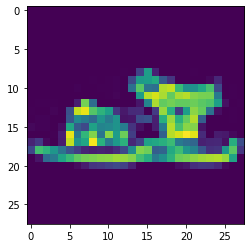

In [58]:
image, label = training_data[121]
image.shape
plt.imshow(image[0])

Обращение к набору данных по индексу возвращает кортеж из двух элементов: тензор с изображением и номер класса. Преобразование `ToTensor()` переводит изображение в тензор и приводит значения пикселей к диапазону [0, 1].

### DataLoader

`DataLoader` объединяет отдельные образцы в мини-выборки (батчи). При обучении сети изображения подаются на вход именно мини-выборками.

In [60]:
batch_size = 4

train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)

images, labels = next(iter(train_loader))
print("Размерность мини-выборки [N, C, H, W]:", images.shape)
print("Размерность меток:", labels.shape)

Размерность мини-выборки [N, C, H, W]: torch.Size([4, 1, 28, 28])
Размерность меток: torch.Size([4])


In [61]:
x, y = next(iter(train_loader))
x.shape, y.shape
print(y)

tensor([2, 2, 1, 7])


Покажем изображения из первой мини-выборки.

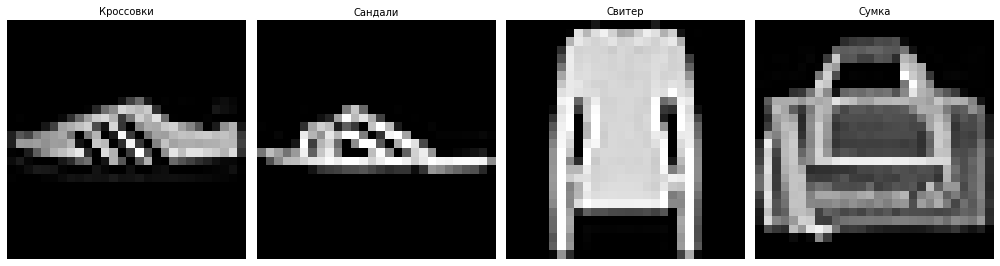

In [62]:
class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Плащ',
               'Сандали', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

fig, axes = plt.subplots(1, batch_size, figsize=(14, 4))
for i in range(batch_size):
    axes[i].imshow(images[i, 0], cmap="gray")
    axes[i].set_title(class_names[labels[i]], fontsize=10)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Свой загрузчик данных

В реальных задачах изображения лежат в файлах на диске, и для них нужно написать собственный класс `Dataset`, который при каждом обращении считывает изображение. Ниже класс, который читает все файлы `.jpg` из заданной папки. Примеры изображений лежат в папке `data/images`.

In [67]:
image_folder = "images"

image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))
print("Найдено изображений:", len(image_paths))
print(*[os.path.basename(p) for p in image_paths], sep="\n")

Найдено изображений: 5
profile.jpg
horse.jpg
frog.jpg
plane.jpg
enface.jpg


In [64]:
class ImagesDataset(Dataset):
    """Dataset для чтения изображений из папки."""

    def __init__(self, folder, transform=None):
        # Запоминаем пути ко всем изображениям в папке
        self.image_paths = glob.glob(os.path.join(folder, "*.jpg"))
        self.transform = transform

    def __len__(self):
        # Количество образцов в наборе данных
        return len(self.image_paths)

    def __getitem__(self, index):
        # Путь к изображению
        image_path = self.image_paths[index]
        # Считываем изображение с диска
        image = Image.open(image_path).convert("RGB")
        # Преобразуем его в тензор
        if self.transform is not None:
            image = self.transform(image)
        return image, image_path

Метод `__getitem__` вызывается `DataLoader` для каждого образца. Момент считывания изображения с диска (`Image.open`) происходит именно здесь.

Создадим набор данных. Преобразование `Resize` приводит все изображения к одному размеру, а `ToTensor` переводит их в тензоры.

In [68]:
transform = Compose([
    Resize((64, 64)),   # все изображения к размеру 128x128
    ToTensor(),           # PIL Image -> тензор [C, H, W]
])

images_dataset = ImagesDataset(image_folder, transform=transform)
print("Количество изображений:", len(images_dataset))

image, path = images_dataset[0]
print("Файл:", path)
print("Размерность тензора:", image.shape)

Количество изображений: 5
Файл: images/profile.jpg
Размерность тензора: torch.Size([3, 64, 64])


In [70]:
image.shape

torch.Size([3, 64, 64])

In [71]:
images_dataset[0][0].shape

torch.Size([3, 64, 64])

In [83]:
image = images_dataset[1][0]
image.shape

torch.Size([3, 64, 64])

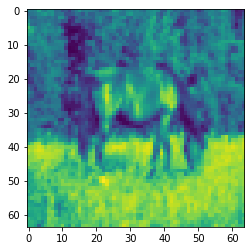

In [84]:
plt.imshow(image[0])

In [86]:
image_loader

Теперь поместим изображения в `DataLoader` и посмотрим, как выглядят мини-выборки.

Размерность мини-выборки: torch.Size([4, 3, 64, 64])


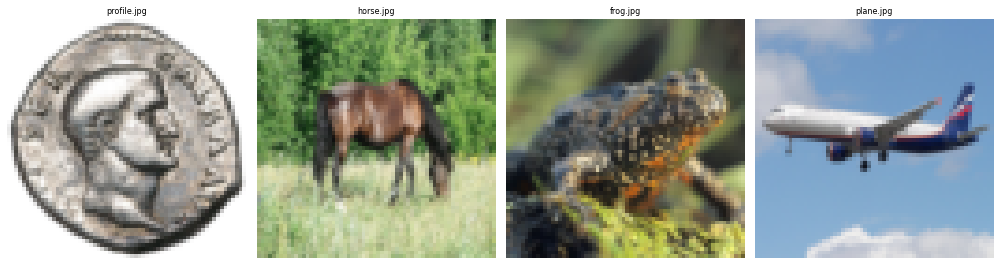

In [87]:
image_loader = DataLoader(images_dataset, batch_size=4)

images, paths = next(iter(image_loader))
print("Размерность мини-выборки:", images.shape)

fig, axes = plt.subplots(1, images.shape[0], figsize=(14, 4))
for i in range(images.shape[0]):
    # Переставляем оси из [C, H, W] в [H, W, C] для matplotlib
    img = images[i].permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(paths[i]), fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Что дальше?

Мы познакомились с тензорами, основными операциями и автоматическим дифференцированием. В следующих уроках вы узнаете, как на этой основе строить и обучать настоящие нейронные сети:

* модуль `torch.nn` - готовые слои и функции ошибки;
* модуль `torch.optim` - алгоритмы оптимизации (например, Adam);
* класс `Dataset` и `DataLoader` - загрузка данных мини-выборками.

Начнем с [обучения полносвязной сети на данных FashionMNIST](../01_introduction/pytorch/fashion_mnist_dense.ipynb).